In [ ]:
library(Seurat)
#library(SeuratData)
library(patchwork)
library(ggplot2)
library(purrr)
library(dplyr)
library(stringr)

In [24]:
GCA_obj <- readRDS('GCA_obj_subset_excludecells3.Rdata')

In [25]:
GCA_obj

An object of class Seurat 
36601 features across 46912 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.cca, umap

In [29]:
GCA_obj_Tcell <- readRDS('GCA_obj_subset_Tcelltype2.Rdata')
GCA_obj_Myloied <- readRDS('GCA_obj_subset_Myloied.Rdata')

In [30]:
GCA_obj@meta.data %>% dplyr::count(sample) -> Total_cellnumber

In [31]:
options(repr.plot.height=6,repr.plot.width=6)
p_total_bar <- ggplot(data =Total_cellnumber) + geom_bar(aes(x=sample,y=n),fill="#018571",stat='identity')+theme_bw()+
    theme(axis.text.x = element_text(angle=45,hjust=1,color='black'),
          axis.text.y=element_text(color="black"))+ylab("Total cell number")+xlab('')

In [23]:
saveRDS(Total_cellnumber,
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig21a.Rds")

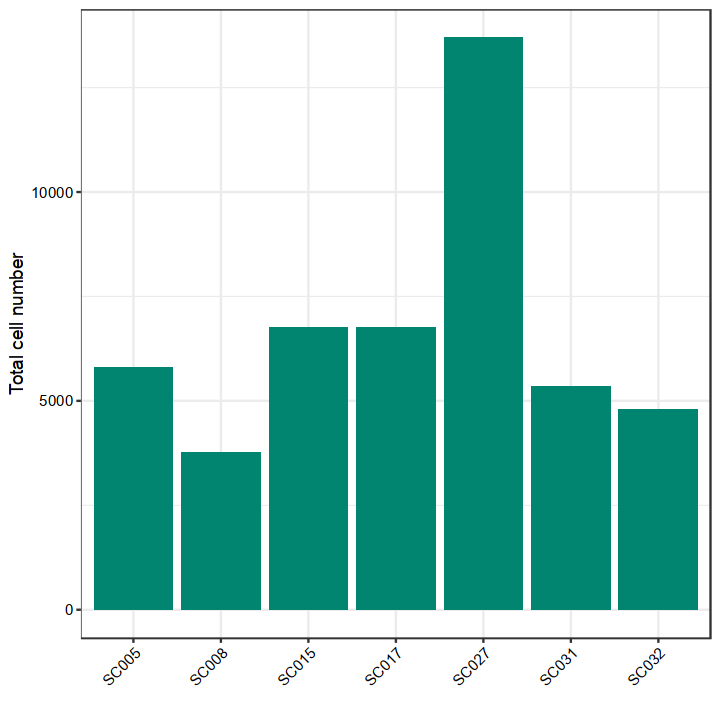

In [32]:
p_total_bar

In [33]:
options(repr.plot.height=6,repr.plot.width=8)
p_vln_nFreature = VlnPlot(GCA_obj,  pt.size = 0,split.by = "sample",  group.by = 'sample',
        features = c("nFeature_RNA"),  ncol = 1)+geom_hline(yintercept = c(500,7000),linetype = "dashed")

In [25]:
saveRDS(GCA_obj@meta.data  %>% select(nFeature_RNA),
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig21c.Rds")

In [26]:
saveRDS(GCA_obj@meta.data  %>% select(nCount_RNA),
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig21b.Rds")

In [27]:
saveRDS(GCA_obj@meta.data  %>% select(percent.mt),
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig21d.Rds")

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_hline()`).”


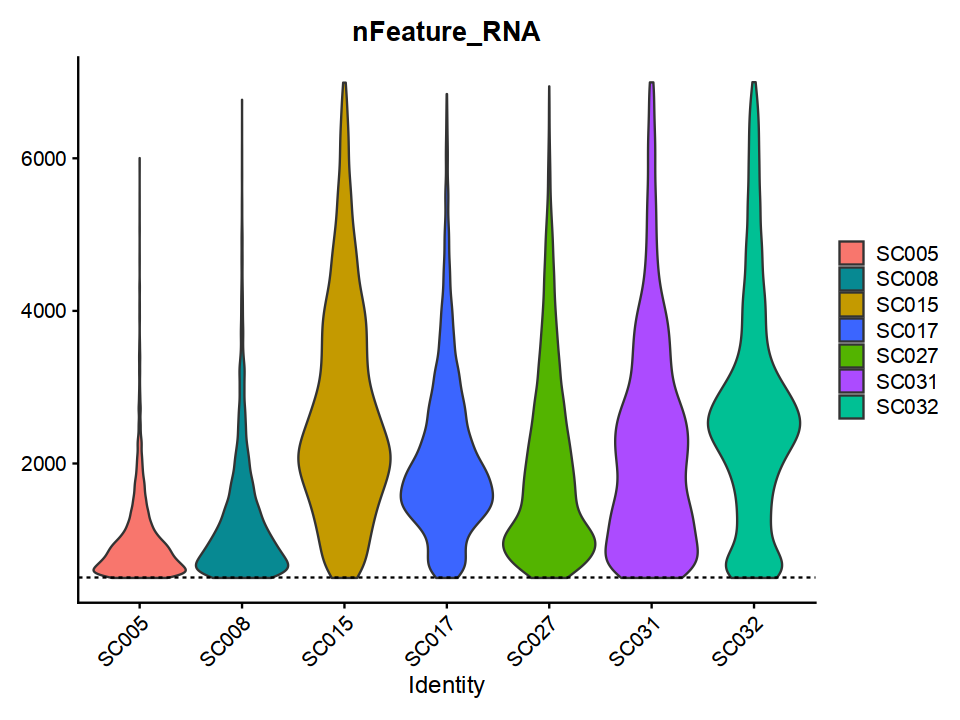

In [34]:
p_vln_nFreature

In [35]:
options(repr.plot.height=6,repr.plot.width=8)
p_vln_nCount = VlnPlot(GCA_obj,  pt.size = 0,split.by = "sample",  group.by = 'sample',
        features = c("nCount_RNA"),  ncol = 1)+geom_hline(yintercept = c(100,50000),linetype = "dashed")+ylim(c(0,100000))

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


In [36]:
options(repr.plot.height=6,repr.plot.width=8)
p_vln_MT = VlnPlot(GCA_obj,  pt.size = 0,split.by = "sample",  group.by = 'sample',
        features = c("percent.mt"),  ncol = 1)+geom_hline(yintercept = c(0,20),linetype = "dashed")

In [ ]:
ggsave(filename = paste0("01.VlnPlot/p_vln_nFeature.pdf"),plot = p_vln_nFreature,width = 8,height =6)
ggsave(filename = paste0("01.VlnPlot/p_vln_nCount.pdf"),plot = p_vln_nCount,width = 8,height =6)
ggsave(filename = paste0("01.VlnPlot/p_vln_MT.pdf"),plot = p_vln_MT,width = 8,height =6)

In [37]:
GCA_obj@meta.data   %>% mutate(Maincelltype=ifelse(celltype=='Plasma','Lymphocyte',Maincelltype)) ->GCA_obj@meta.data 

In [38]:
#saveRDS(GCA_obj,'GCA_obj_subset_excludecells3.Rdata')

In [39]:
GCA_obj@meta.data  %>% head()

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,RNA_snn_res.1.2,seurat_clusters,Maincelltype,subcelltype,celltype,temp
,<fct>,<dbl>,<dbl>,<chr>,<dbl>,<fct>,<fct>,<chr>,<fct>,<chr>,<dbl>
AAACCCAAGACTCTTG-1-SC005,SeuratProject,1864,1114,SC005,4.560086,12,12,Lymphocyte,Tcells,CD4+ T,5.0
AAACCCAAGAGCATTA-1-SC005,SeuratProject,4430,2242,SC005,1.602709,26,26,Stroma,Endothelial,Endothelial,0.1
AAACCCAAGCAACTTC-1-SC005,SeuratProject,2869,825,SC005,1.707912,0,0,Lymphocyte,Plasma,Plasma,0.1
AAACCCAAGCGTTGTT-1-SC005,SeuratProject,1095,732,SC005,2.557078,40,40,Lymphocyte,Tcells,Regulatory T,0.0
AAACCCAAGTACTGGG-1-SC005,SeuratProject,1236,808,SC005,3.236246,57,57,Lymphocyte,Tcells,NKcell,6.0
AAACCCACAAGCTGCC-1-SC005,SeuratProject,667,508,SC005,2.548726,50,50,Lymphocyte,Tcells,Regulatory T,3.0


In [40]:
# Visualization
options(repr.plot.height=8,repr.plot.width=8)
pdimplot <- DimPlot(GCA_obj, reduction = "umap",group.by = c("Maincelltype"),label = TRUE,ncol=1)

In [28]:
saveRDS(GCA_obj@meta.data  %>% select(Maincelltype),
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig21e.Rds")

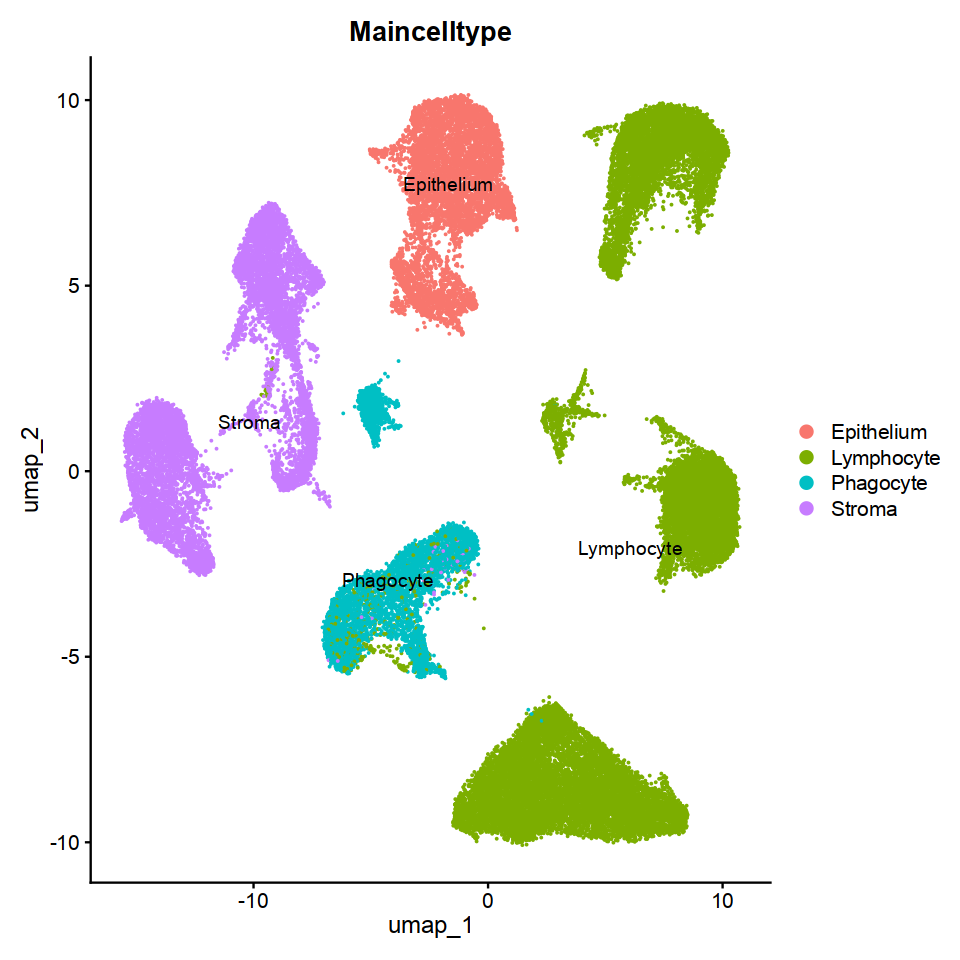

In [41]:
pdimplot

In [42]:
library(RColorBrewer )

In [43]:
GCA_obj$subcelltype  %>% unique()

[1] Tcells       Endothelial  Plasma       MyeloidCells Bcell       
 [6] Musclecell   Epi_tumor    Mastcell     Fibroblasts  Pericyte    
[11] Epi_normal  
11 Levels: Tcells Endothelial Plasma MyeloidCells Bcell ... Pericyte

In [10]:
GCA_obj$subcelltype  <- factor(GCA_obj$subcelltype ,levels = c(
    'Epi_tumor','Epi_normal','Bcell','Tcells','Endothelial',
    'Fibroblasts', 'Mastcell','Musclecell','MyeloidCells','Pericyte',
    'Plasma'))

In [11]:
GCA_obj$subcelltype  %>% unique()

[1] Tcells       Endothelial  Plasma       MyeloidCells Bcell       
 [6] Musclecell   Epi_tumor    Mastcell     Fibroblasts  Pericyte    
[11] Epi_normal  
11 Levels: Epi_tumor Epi_normal Bcell Tcells Endothelial ... Plasma

In [12]:
colorpatalee <- c('#9E0142','#D53E4F','#D53E4F','#FDAE61','#FFB600',
                  '#FF47E3','#E6F598','#aae85a','#88CFA4','#486BAF',
                  '#5E4FA2')

In [13]:
# Visualization
options(repr.plot.height=8,repr.plot.width=8)
pdimplot <- DimPlot(GCA_obj, reduction = "umap",group.by = c("subcelltype"),label = TRUE,ncol=1,
                  raster.dpi = c(300, 300),  raster = TRUE,
                    cols = colorpatalee)

In [14]:
# Visualization
options(repr.plot.height=8,repr.plot.width=8)
pdimplot_compart <- DimPlot(GCA_obj, reduction = "umap",group.by = c("Maincelltype"),label = TRUE,ncol=1, 
                            raster = TRUE, raster.dpi = c(300, 300) )

In [21]:
umap_df <- Embeddings(GCA_obj, reduction = "umap")
head(umap_df)

,umap_1,umap_2
AAACCCAAGACTCTTG-1-SC005,4.3006863,-9.8492132
AAACCCAAGAGCATTA-1-SC005,-14.0900879,-0.9465348
AAACCCAAGCAACTTC-1-SC005,8.0325374,9.5272755
AAACCCAAGCGTTGTT-1-SC005,0.2856141,-9.2732740
AAACCCAAGTACTGGG-1-SC005,5.6374731,-8.5872989
AAACCCACAAGCTGCC-1-SC005,-1.3974136,-8.8376298


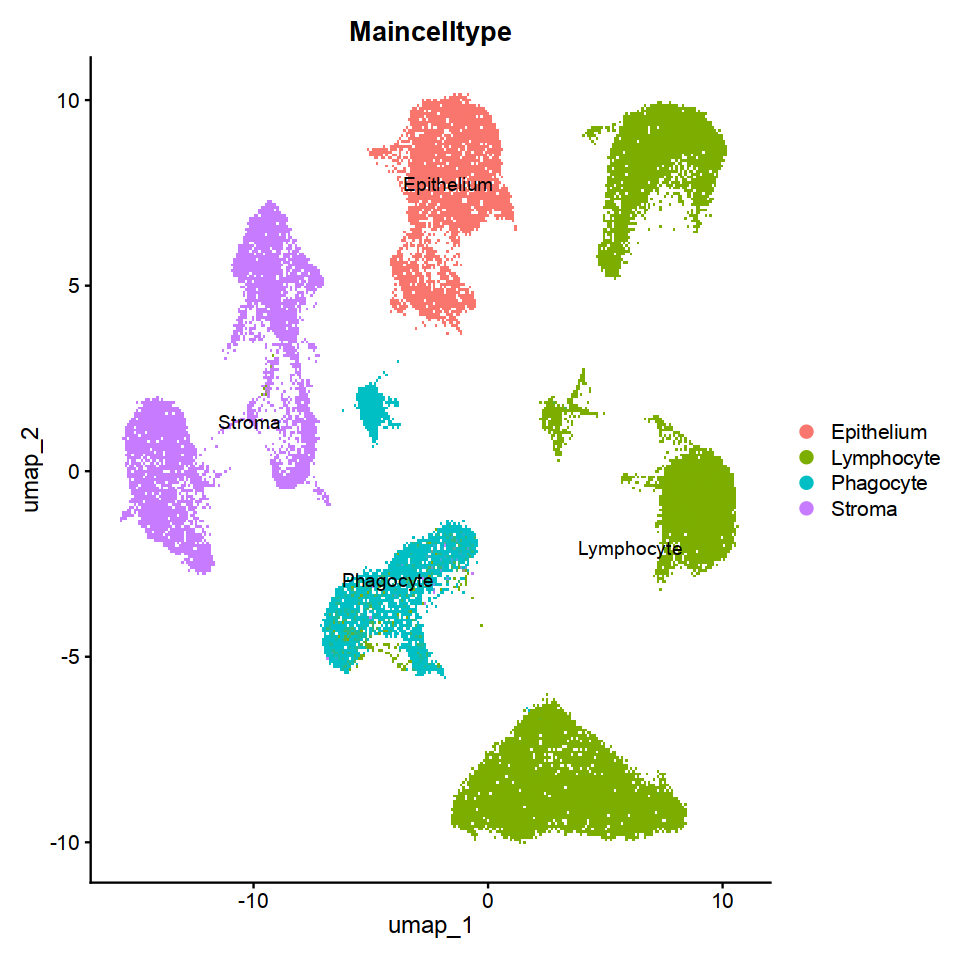

In [15]:
pdimplot_compart

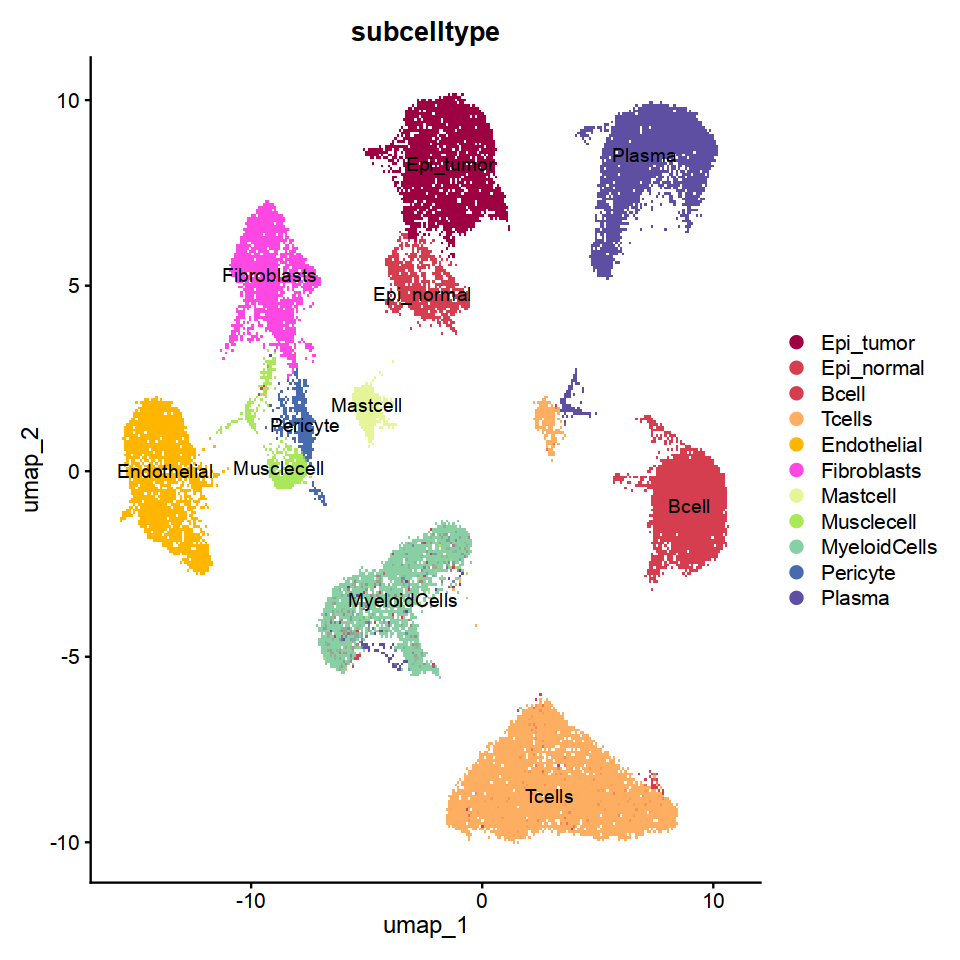

In [16]:
pdimplot

In [17]:
ggsave(filename = "UMAP_AllCelltypes.pdf",plot = pdimplot,width = 8,height = 8)

In [18]:
ggsave(filename = "UMAP_AllCompartments.pdf",plot = pdimplot_compart,width = 8,height = 8)

In [19]:
# Visualization
p_dim_split <- DimPlot(GCA_obj, reduction = "umap", group.by = c("subcelltype"),
                       raster = TRUE,pt.size = 2,split.by="sample",ncol=4, 
                  raster.dpi = c(512, 512),
                       cols = colorpatalee)

In [20]:
# Visualization
p_dim_split2 <- DimPlot(GCA_obj, reduction = "umap", group.by = c("Maincelltype"),
                       raster = TRUE,pt.size = 2,split.by="sample",ncol=4,
                  raster.dpi = c(512, 512))

In [46]:
plot_dfaabb <- cbind(
  as.data.frame(Embeddings(GCA_obj, reduction = "umap")),
  subcelltype = GCA_obj@meta.data$subcelltype,
  sample = GCA_obj@meta.data$sample
)

head(plot_df)

,umap_1,umap_2,newtypes
,<dbl>,<dbl>,<fct>
AAACCCAGTAAGGCCA-1-SC005,0.3767851,1.576958,Neutrophils
AAACGAACAGGCCCTA-1-SC005,0.4657261,-5.211279,MacrophageM2
AAACGAATCACTGATG-1-SC005,3.1230736,1.843538,Monocytes
AAACGCTAGACTTAAG-1-SC005,3.2322645,2.158723,Neutrophils
AAACGCTTCAACCTTT-1-SC005,0.4947072,1.605595,Monocytes
AAAGAACAGCGAGGAG-1-SC005,2.4002073,3.088694,Monocytes


In [47]:
saveRDS(plot_dfaabb,
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig22d.Rds")

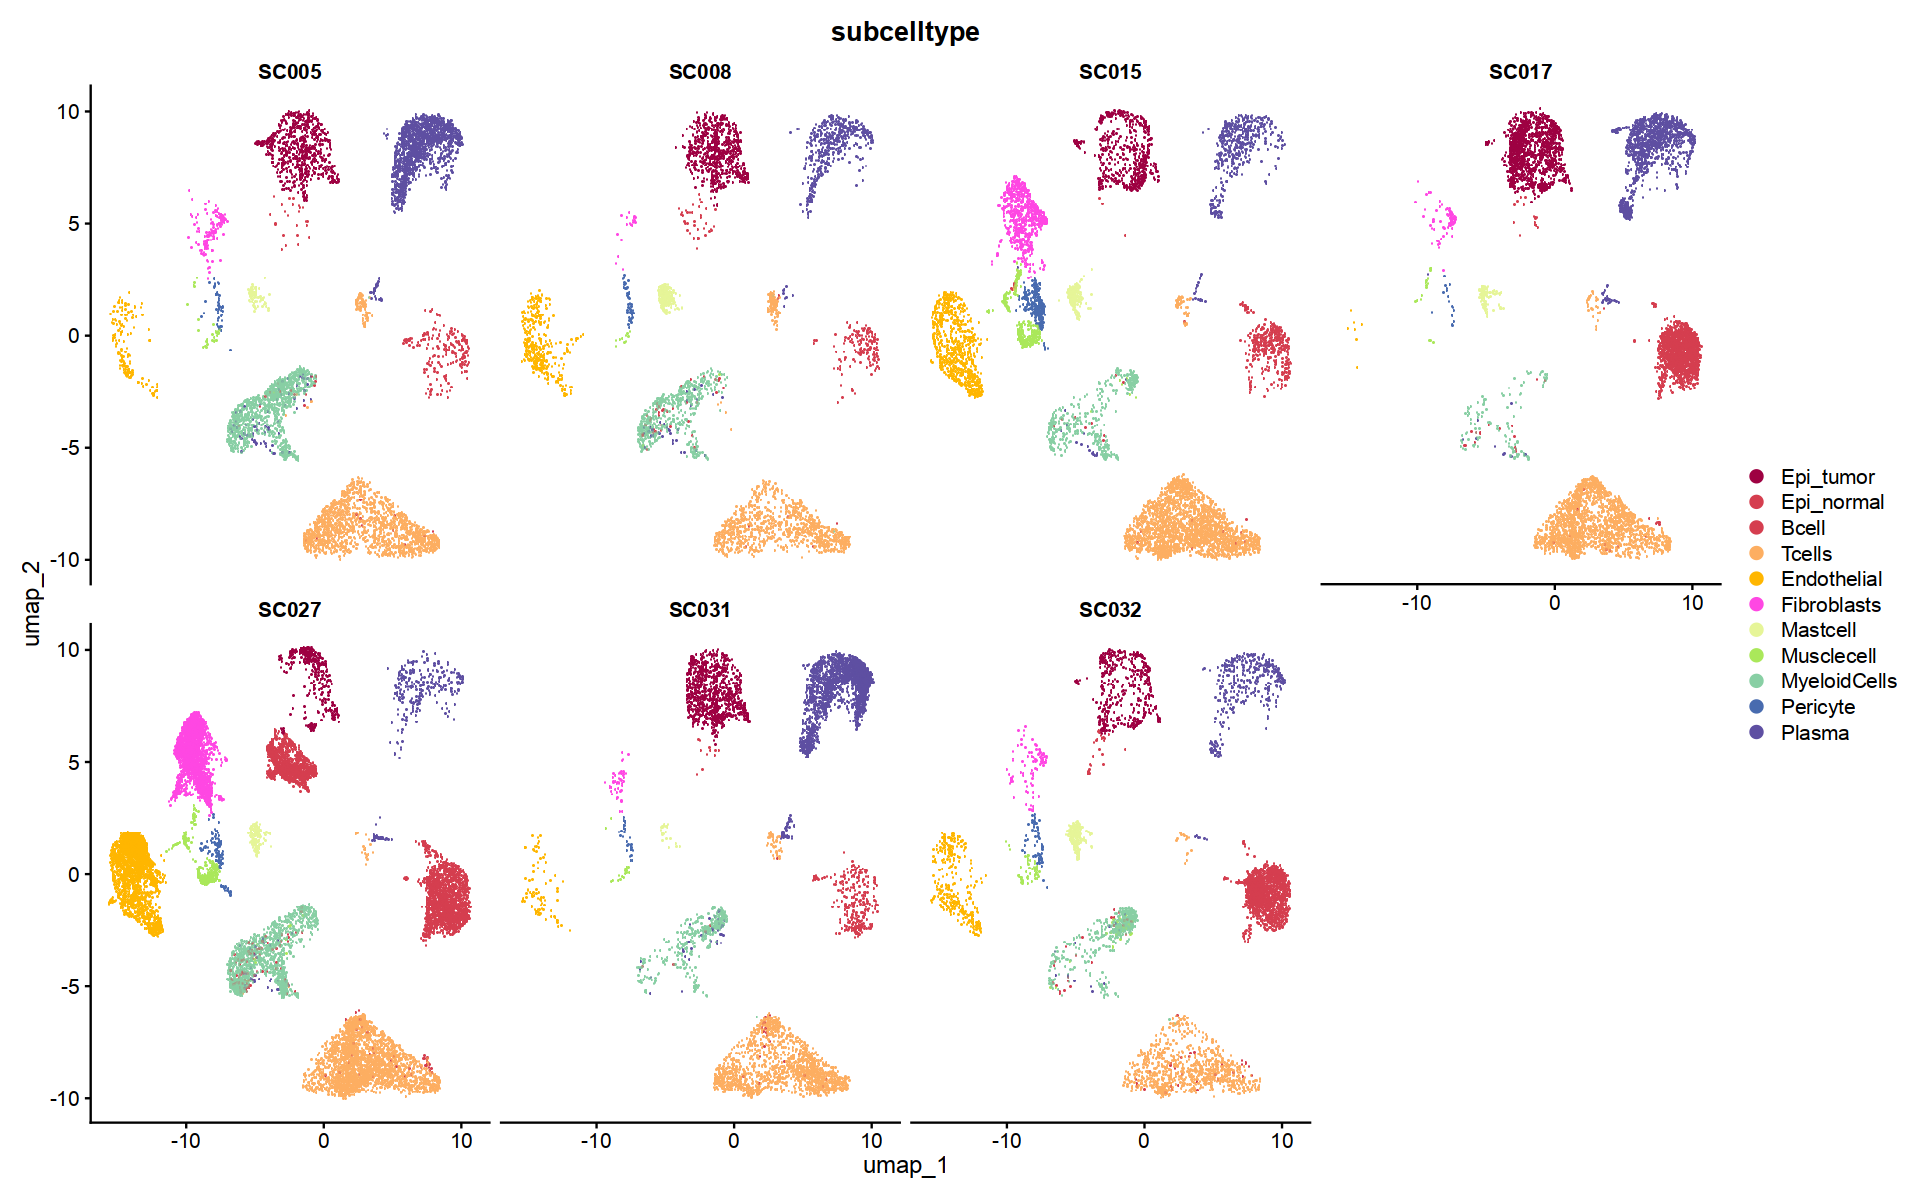

In [21]:
options(repr.plot.height=10,repr.plot.width=16)
p_dim_split

In [22]:
ggsave(filename = "UMAP_AllCelltypes_SplitSample.pdf",plot =p_dim_split,width = 16,height = 10)

In [23]:
ggsave(filename = "UMAP_AllCompartments_SplitSample.pdf",plot =p_dim_split2,width = 16,height = 10)

In [373]:
genes <- c( 'KRT8', 'MUC1', 'EPCAM', ### Epi_tumor
            'KRT6A', 'DSG3', 'LYPD3',## Epi_normal
            'BANK1', 'MS4A1', 'BACH2',   ## Bcell
            'BCL11B', 'CD2', 'CD3D',  ## Tcells
            'EMCN', 'ADGRL4', 'LDB2', ##Endothelial
            'DPT', 'FBLN1','LAMA2', ## Fibroblasts
            'CPA3', 'HPGDS', 'TPSAB1',## Mastcell
            'MYH11','CNN1', 'LMOD1', ## Musclecell
            'TYROBP','MS4A7',  'AIF1', ## MyeloidCells   
            'RGS5', 'NOTCH3', "PDGFRB",## Pericyte
            'MZB1', 'DERL3', 'FKBP11' ### Plasma
          )

In [381]:
GCA_obj@meta.data$subcelltype  <- factor(GCA_obj@meta.data$subcelltype,
                                                         levels = rev(c(
                                            'Epi_tumor','Epi_normal','Bcell','Tcells','Endothelial',
                                            'Fibroblasts', 'Mastcell','Musclecell',
                                            'MyeloidCells',
                                            'Pericyte','Plasma')))

In [382]:
Idents(GCA_obj) <- 'subcelltype'
p_markergenes_all <- DotPlot(GCA_obj, features = rev(genes)) + RotatedAxis()

In [15]:
saveRDS(p_markergenes_all$data,
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig22a.Rds")

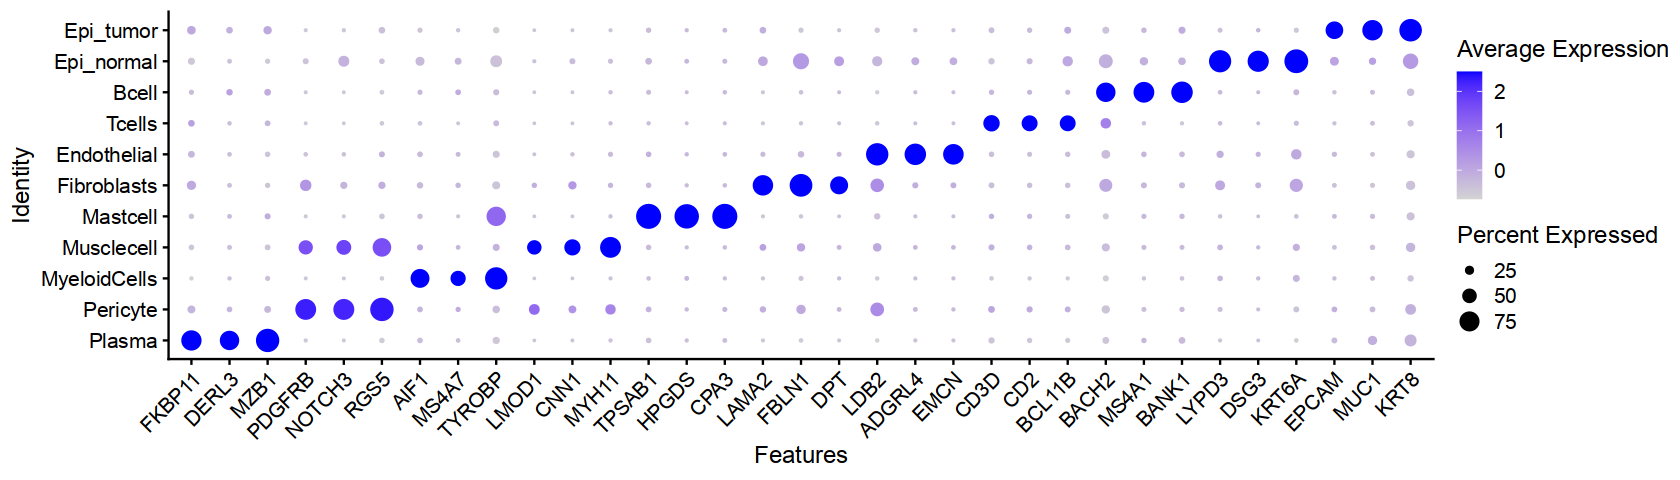

In [383]:
options(repr.plot.height=4,repr.plot.width=14)
p_markergenes_all

In [384]:
ggsave(filename = "All_markergene_bubbleplot.pdf",plot =p_markergenes_all,width = 14,height = 4)

In [ ]:
GCA_obj <- ScaleData(GCA_obj, features = rownames(GCA_obj))

In [ ]:
Idents(GCA_obj) <- GCA_obj$subcelltype

# find markers for every cluster compared to all remaining cells, report only the positive
GCA_obj.markers <- FindAllMarkers(GCA_obj, only.pos = TRUE)

In [2]:
GCA_obj.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 10) %>%
    ungroup() -> top10

ERROR: Error in GCA_obj.markers %>% group_by(cluster) %>% dplyr::filter(avg_log2FC > : could not find function "%>%"


In [267]:
GCA_obj$celltype <- factor(GCA_obj$celltype,levels = c(
    'Epi_tumor','Epi_normal','Bcell','Tcells','Endothelial',
    'Fibroblasts', 'Mastcell','Musclecell',
    'MyeloidCells',
    'Pericyte','Plasma'))

In [390]:
pdf(file = "Heatmap_Top10_differential.pdf",height = 20,width = 20)
options(repr.plot.height=20,repr.plot.width=20)
DoHeatmap(subset(GCA_obj), features = top10$gene,) + NoLegend()+
    scale_fill_gradientn(colors = c( 'lightblue',"white", "red"))
dev.off()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


png 
  2

In [6]:
expr_mat <- GetAssayData(
  subset(GCA_obj),
  slot = "scale.data"
)

expr_mat <- expr_mat[top10$gene, ]
expr_mat[1:5, 1:5]

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


,AAACCCAAGACTCTTG-1-SC005,AAACCCAAGAGCATTA-1-SC005,AAACCCAAGCAACTTC-1-SC005,AAACCCAAGCGTTGTT-1-SC005,AAACCCAAGTACTGGG-1-SC005
FCGR3B,-0.1433522,-0.1433522,-0.1433522,-0.1433522,-0.1433522
NAMPT,-1.0589855,-0.1190131,0.1356569,0.7842814,-1.0589855
CXCL8,-0.4905191,0.5308051,0.8075161,-0.4905191,-0.4905191
G0S2,-0.3623377,-0.3623377,-0.3623377,-0.3623377,-0.3623377
SOD2,-0.8928106,0.1260276,-0.8928106,-0.8928106,-0.8928106


In [7]:
expr_mat

,AAACCCAAGACTCTTG-1-SC005,AAACCCAAGAGCATTA-1-SC005,AAACCCAAGCAACTTC-1-SC005,AAACCCAAGCGTTGTT-1-SC005,AAACCCAAGTACTGGG-1-SC005,AAACCCACAAGCTGCC-1-SC005,AAACCCAGTAAGGCCA-1-SC005,AAACCCAGTCGATTTG-1-SC005,AAACCCAGTCTCACGG-1-SC005,AAACGAAAGCCATATC-1-SC005,⋯,TTTGATCTCCGTGTGG-1-SC032,TTTGGAGCAACCGCCA-1-SC032,TTTGGAGGTCCAAAGG-1-SC032,TTTGGAGTCAGTGCGC-1-SC032,TTTGGAGTCTTGAACG-1-SC032,TTTGGTTAGTCTGCGC-1-SC032,TTTGTTGGTATGAGAT-1-SC032,TTTGTTGGTTTCACTT-1-SC032,TTTGTTGTCAAGGCTT-1-SC032,TTTGTTGTCACATCAG-1-SC032
FCGR3B,-0.14335220,-0.14335220,-0.14335220,-0.14335220,-0.14335220,-0.14335220,-0.14335220,-0.14335220,-0.14335220,-0.14335220,⋯,-0.14335220,-0.14335220,-0.14335220,3.18678960,-0.14335220,-0.14335220,-0.14335220,-0.14335220,-0.14335220,-0.14335220
NAMPT,-1.05898555,-0.11901311,0.13565689,0.78428138,-1.05898555,1.67399089,2.11068928,-1.05898555,0.56462923,1.64012635,⋯,0.50608848,-0.21138968,-0.07249221,-0.18621417,-1.05898555,-1.05898555,-0.42286909,0.96647814,-0.40980884,1.12055274
CXCL8,-0.49051913,0.53080514,0.80751607,-0.49051913,-0.49051913,-0.49051913,-0.49051913,-0.49051913,-0.49051913,-0.49051913,⋯,0.11925746,-0.49051913,-0.49051913,0.45778803,-0.49051913,-0.11880614,0.20065132,0.23144458,-0.06783800,1.29353654
G0S2,-0.36233768,-0.36233768,-0.36233768,-0.36233768,-0.36233768,-0.36233768,-0.36233768,-0.36233768,-0.36233768,2.78984378,⋯,0.45147405,0.40862855,-0.36233768,-0.36233768,1.89368090,0.13375285,-0.36233768,0.60119971,-0.36233768,-0.36233768
SOD2,-0.89281064,0.12602765,-0.89281064,-0.89281064,-0.89281064,2.06946879,2.20099539,-0.89281064,-0.89281064,1.46332132,⋯,-0.28451830,0.02590047,0.17645176,0.05318826,0.79347473,-0.52200243,-0.89281064,-0.89281064,-0.18916652,0.80374654
ADGRG3,-0.12937947,-0.12937947,-0.12937947,-0.12937947,-0.12937947,-0.12937947,-0.12937947,8.07658999,-0.12937947,-0.12937947,⋯,-0.12937947,-0.12937947,-0.12937947,-0.12937947,-0.12937947,-0.12937947,-0.12937947,-0.12937947,-0.12937947,-0.12937947
IFITM2,-0.83882928,1.15808354,0.62278506,1.41636047,1.93062995,1.86080725,2.00495558,-0.83882928,2.60798442,-0.83882928,⋯,0.74701679,0.47415396,0.36811998,0.22898409,-0.83882928,0.96426647,0.66225609,-0.83882928,0.19491963,-0.53832484
ALOX5AP,2.25530114,-0.55672476,-0.55672476,-0.55672476,-0.55672476,-0.55672476,-0.55672476,1.85434006,-0.55672476,-0.55672476,⋯,0.24853220,-0.55672476,-0.55672476,-0.55672476,-0.55672476,-0.55672476,-0.55672476,-0.55672476,2.05274079,-0.55672476
CMTM2,-0.13054605,-0.13054605,-0.13054605,-0.13054605,-0.13054605,-0.13054605,-0.13054605,-0.13054605,-0.13054605,-0.13054605,⋯,-0.13054605,-0.13054605,-0.13054605,-0.13054605,-0.13054605,-0.13054605,-0.13054605,-0.13054605,-0.13054605,-0.13054605
SLC25A37,-0.46530791,-0.46530791,-0.46530791,-0.46530791,-0.46530791,-0.46530791,-0.46530791,-0.46530791,-0.46530791,-0.46530791,⋯,0.66773413,-0.46530791,-0.46530791,-0.46530791,-0.46530791,2.04157092,1.52356824,0.87619201,0.32008710,0.40898430


In [9]:
GCA_obj@meta.data   %>% select(subcelltype)

,subcelltype
,<fct>
AAACCCAAGACTCTTG-1-SC005,Tcells
AAACCCAAGAGCATTA-1-SC005,Endothelial
AAACCCAAGCAACTTC-1-SC005,Plasma
AAACCCAAGCGTTGTT-1-SC005,Tcells
AAACCCAAGTACTGGG-1-SC005,Tcells
AAACCCACAAGCTGCC-1-SC005,Tcells
AAACCCAGTAAGGCCA-1-SC005,MyeloidCells
AAACCCAGTCGATTTG-1-SC005,Tcells
AAACCCAGTCTCACGG-1-SC005,Bcell


In [10]:
saveRDS(list(expr_mat = expr_mat,celltype = GCA_obj@meta.data   %>% select(subcelltype)),
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig22b.Rds")

In [12]:
#pdf(file = "UMAP_AllCeltype_Markergenes.pdf",height = 20,width = 12)
FeaturePlot(GCA_obj, features = genes,raster =TRUE,cols = c("lightgrey", "red"),pt.size = 3,
           raster.dpi = c(1024, 1024))
#dev.off()

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


In [13]:
p_feature <- FeaturePlot(
  GCA_obj,
  features = genes
)

feature_data <- p_feature$data
head(feature_data)

,umap_1,umap_2,ident,FKBP11
,<dbl>,<dbl>,<fct>,<dbl>
AAACCCAAGACTCTTG-1-SC005,4.3006863,-9.8492132,Tcells,0.000000
AAACCCAAGAGCATTA-1-SC005,-14.0900879,-0.9465348,Endothelial,0.000000
AAACCCAAGCAACTTC-1-SC005,8.0325374,9.5272755,Plasma,1.500858
AAACCCAAGCGTTGTT-1-SC005,0.2856141,-9.2732740,Tcells,0.000000
AAACCCAAGTACTGGG-1-SC005,5.6374731,-8.5872989,Tcells,0.000000
AAACCCACAAGCTGCC-1-SC005,-1.3974136,-8.8376298,Tcells,0.000000


In [14]:
saveRDS(feature_data,
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig22c.Rds")

### compare 

In [74]:
ERBB2_group <- read.table('../04.groupERBB2/ERBB2_7.txt',header=T)
ERBB2_group$sample <- rownames(ERBB2_group)

In [75]:
GCA_obj@meta.data -> metadata

In [76]:
metadata$celltype <- as.character(metadata$celltype)

In [77]:
metadata$celltype  %>%  unique()

[1] "CD4+ T"         "Endothelial"    "Plasma"         "Regulatory T"  
 [5] "NKcell"         "Neutrophils"    "Bcell"          "CD8+ Low"      
 [9] "MacrophageM2"   "Musclecell"     "Epi_tumor"      "Monocytes"     
[13] "CD8+ T"         "MacrophageM1"   "Mastcell"       "DendriticCells"
[17] "Fibroblasts"    "Pericyte"       "Epi_normal"

In [78]:
metadata %>% count(sample,celltype) -> sample_subcelltype_number

In [79]:
sample_subcelltype_number %>% group_by(sample) %>% 
    reframe(Percentage = n/sum(n),celltype = celltype)%>% as.data.frame() -> sample_subcelltype_number2

In [80]:
sample_subcelltype_number2$sample <-  factor(sample_subcelltype_number2$sample,levels = rownames(ERBB2_group))

In [81]:
right_join(sample_subcelltype_number2,ERBB2_group,by = "sample") -> sample_subcelltype_number2

In [82]:
sample_subcelltype_number2 %>% mutate(group = ifelse(ERBB2<7,"Low","High")) -> sample_subcelltype_number2_group

In [83]:
sample_subcelltype_number2_group$group  <- factor(sample_subcelltype_number2_group$group,levels=c('High',"Low"))

In [86]:
library(ggpubr)

In [91]:
p_all_box <- ggboxplot(sample_subcelltype_number2_group,x="group",y="Percentage",add="jitter",add.params=list(shape=21, fill="orange", size=3)
             )+geom_signif(comparisons = list(c("High","Low")),step_increase = 0.1,map_signif_level = F,
                           test = t.test)+ylab("Proportion") + 
            scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))+facet_wrap(~celltype, scale="free")

In [39]:
saveRDS(sample_subcelltype_number2_group,
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Figure5i.Rds")

In [11]:
saveRDS(sample_subcelltype_number2_group,
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig23.Rds")

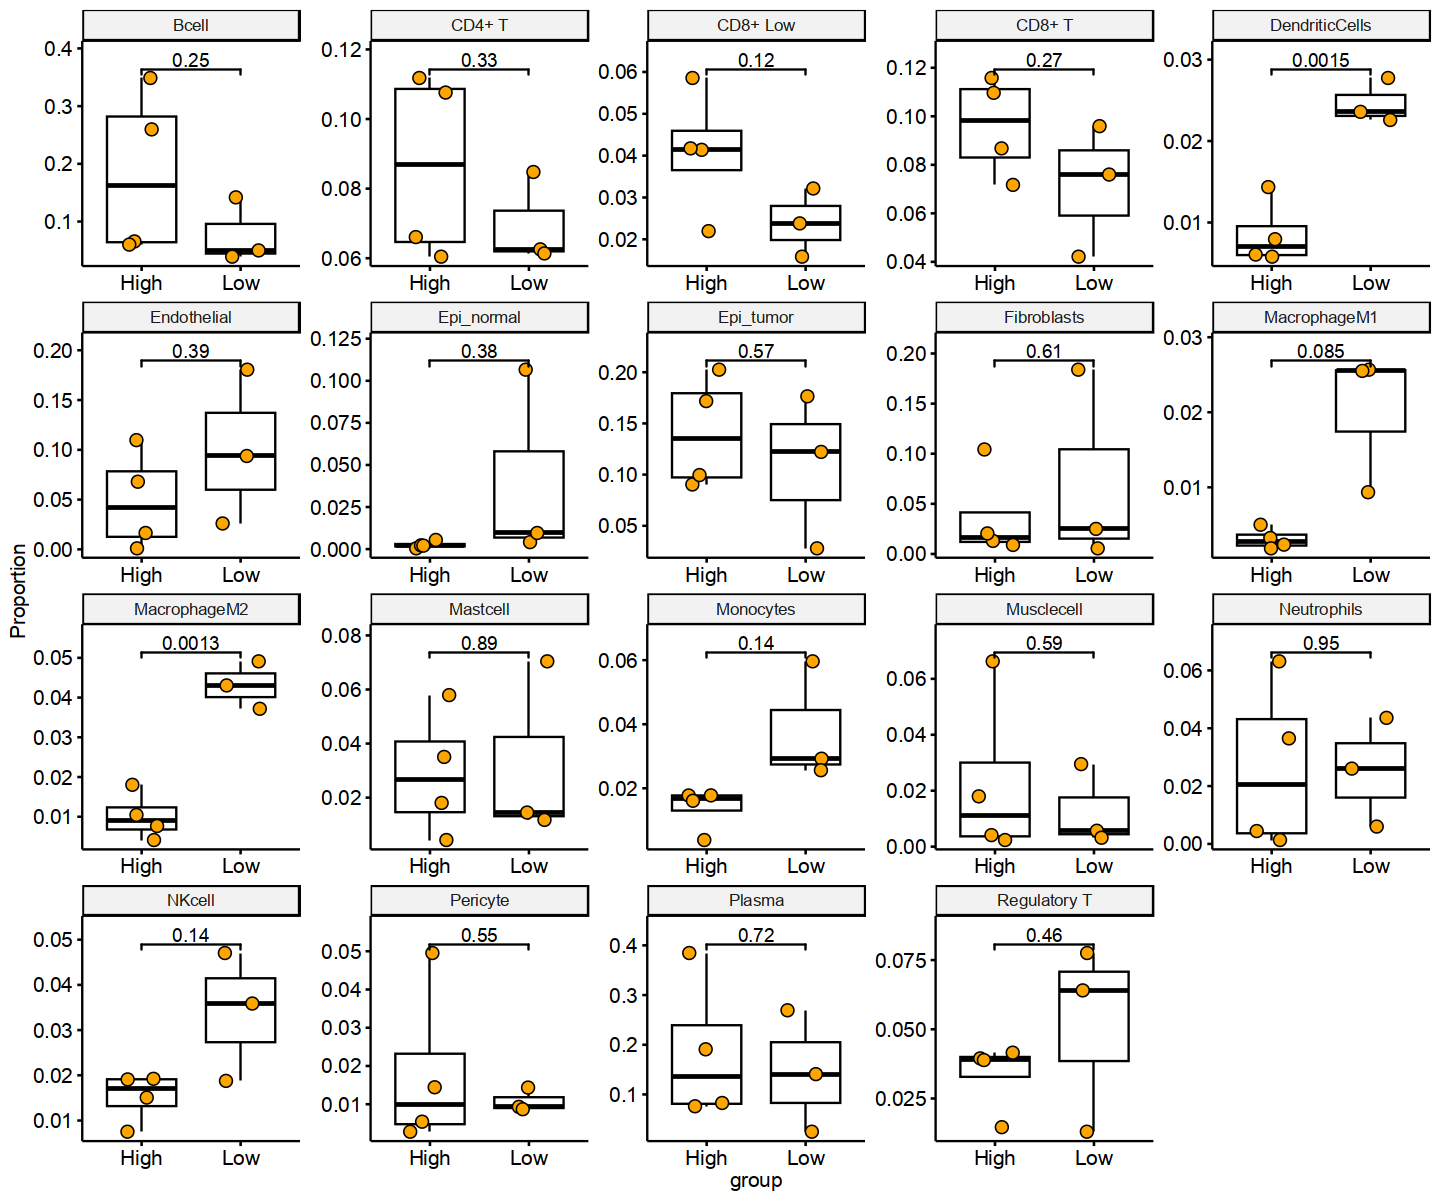

In [92]:
options(repr.plot.height=10,repr.plot.width=12)
p_all_box

In [95]:
ggsave(filename = "UMAP_AllCelltypes_Boxplots.pdf",plot =p_all_box,width = 12,height = 10)

In [4]:
metadata %>% count(sample,celltype) -> sample_subcelltype_number

ERROR: Error in eval(expr, envir, enclos): object 'metadata' not found


In [97]:
sample_subcelltype_number %>% group_by(sample) %>% 
    reframe(Percentage = n/sum(n),celltype = celltype)%>% as.data.frame() -> sample_subcelltype_number2

In [98]:
sample_subcelltype_number2$sample <-  factor(sample_subcelltype_number2$sample,levels = rownames(ERBB2_group))

In [138]:
sample_subcelltype_number2$celltype  %>% unique()

[1] "Bcell"          "CD4+ T"         "CD8+ Low"       "CD8+ T"        
 [5] "DendriticCells" "Endothelial"    "Epi_normal"     "Epi_tumor"     
 [9] "Fibroblasts"    "MacrophageM1"   "MacrophageM2"   "Mastcell"      
[13] "Monocytes"      "Musclecell"     "NKcell"         "Neutrophils"   
[17] "Pericyte"       "Plasma"         "Regulatory T"

In [140]:
sample_subcelltype_number2$celltype  <- factor(sample_subcelltype_number2$celltype,levels = c(
    'Epi_tumor','Epi_normal','Bcell','CD4+ T','Regulatory T','CD8+ T','CD8+ Low','NKcell','Endothelial',
    'Fibroblasts', 'Mastcell','Musclecell','MacrophageM1','MacrophageM2','DendriticCells','Monocytes',
    'Neutrophils','Pericyte','Plasma'))

In [141]:
p_dis <- ggplot(sample_subcelltype_number2, aes(fill=celltype, y=Percentage, x=sample)) + theme_bw()+
    theme(axis.text.x = element_text(angle=45,hjust=1,color='black'))+
    geom_bar(position="stack", stat="identity")

In [135]:
GCA_obj@meta.data$subcelltype  %>% levels

[1] "Tcells"       "Endothelial"  "Plasma"       "MyeloidCells" "Bcell"       
 [6] "Musclecell"   "Epi_tumor"    "Epi_normal"   "Mastcell"     "Fibroblasts" 
[11] "Pericyte"

In [132]:
colorRampPalette(brewer.pal(10, "Spectral"))(11)

[1] "#9E0142" "#CF374D" "#ED6345" "#FA9A58" "#FDCC7A" "#F2EA91" "#CEEB9C"
 [8] "#96D4A4" "#5BB6A9" "#3682BA" "#5E4FA2"

In [142]:
p_dis <- p_dis+ scale_fill_manual(values = colorRampPalette(brewer.pal(10, "Spectral"))(19))

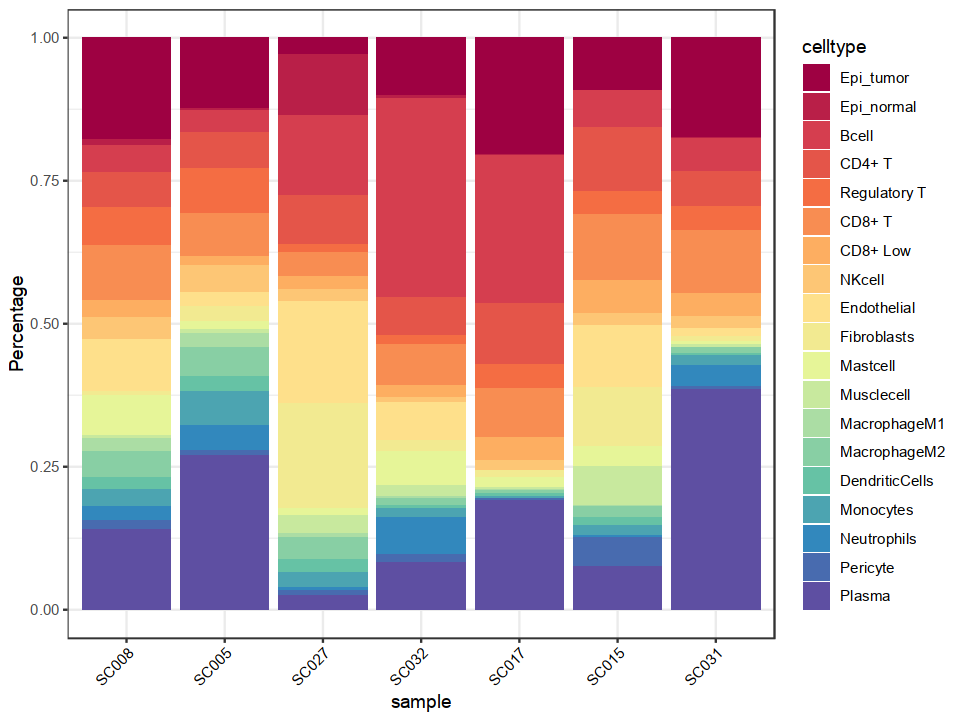

In [143]:
options(repr.plot.height=6,repr.plot.width=8)
p_dis

In [4]:
saveRDS(sample_subcelltype_number2,file = "/disk1/pengweixing/esophageal/30.sourcedata/Figure5f.Rds")

In [164]:
ggsave(filename = "Allbarplot_celltype.pdf",plot =p_dis ,width = 8,height = 6)

In [15]:
sample_subcelltype_number %>% group_by(celltype) %>% 
    reframe(Percentage = n/sum(n),celltype = celltype,sample = sample)%>% 
    as.data.frame() -> sample_subcelltype_number_celltypX

In [16]:
sample_subcelltype_number_celltypX$sample <-  factor(sample_subcelltype_number_celltypX$sample,levels = rownames(ERBB2_group))


In [33]:
p_dis_rev <- ggplot(sample_subcelltype_number_celltypX, aes(fill=sample, y=Percentage, x= celltype)) + theme_bw()+
    theme(axis.text.x = element_text(angle=45,hjust=1,color='black'))+
    geom_bar(position="stack", stat="identity")+
   # scale_fill_manual(values = c('#7fc97f','#beaed4','#fdc086','#ffff99','#386cb0','#f0027f','#bf5b17'))
    scale_fill_manual(values =c('#d73027','#fc8d59','#fee08b','#ffffbf','#d9ef8b','#91cf60','#1a9850'))

In [38]:
saveRDS(sample_subcelltype_number_celltypX,
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Figure5h.Rds")

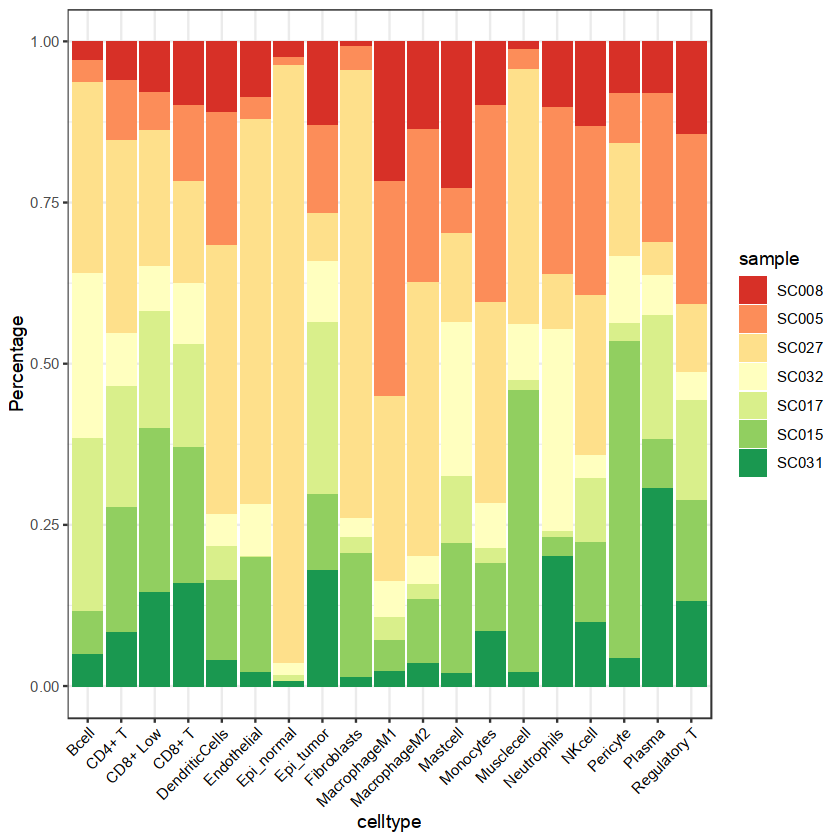

In [34]:
p_dis_rev

In [35]:
ggsave(filename = "Celltype2Patients_bar_distri.pdf",plot =p_dis_rev ,width = 8, height = 6)

### for myeloid

In [47]:
GCA_obj_Myloied@meta.data$newtypes  <- factor(GCA_obj_Myloied@meta.data$newtypes,
                                                         levels = c('Neutrophils','DendriticCells','Monocytes',
                                                                   'MacrophageM2','MacrophageM1'))

In [48]:
myeloidgenes <- c( 'GPNMB', 'APOC1', 'CD9',  ## macrophageM1
            'C1QB', 'C1QC', 'C1QA', ##macrophage M2
            'VCAN', 'EREG', 'FCN1', ### Monocytes
            'CD1C', 'CD1E','FLT3',## Dendritic   
            'FCGR3B', 'CXCL8','NAMPT' ## Neutrophils
          )

In [52]:
Idents(GCA_obj_Myloied) <- 'newtypes'

options(repr.plot.height=4,repr.plot.width=8)
p_myloied_markergenes <- DotPlot(GCA_obj_Myloied, features = myeloidgenes) + RotatedAxis()

In [76]:
allcolors['MacrophageM1']  = '#51bf41'

In [77]:
allcolors['DendriticCells']  = '#417866'

In [78]:
allcolors['Monocytes'] = '#00deff'

In [84]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters 
options(repr.plot.height=6,repr.plot.width=8)
p_umap_myeloid <- DimPlot(GCA_obj_Myloied, reduction = "umap", label = TRUE,group.by ="newtypes" , 
                        #  raster = TRUE, raster.dpi = c(150, 150),
                          cols = allcolors)

In [33]:
umap_df_myeloid <- Embeddings(GCA_obj_Myloied, reduction = "umap")
head(umap_df_myeloid)

,umap_1,umap_2
AAACCCAGTAAGGCCA-1-SC005,0.3767851,1.576958
AAACGAACAGGCCCTA-1-SC005,0.4657261,-5.211279
AAACGAATCACTGATG-1-SC005,3.1230736,1.843538
AAACGCTAGACTTAAG-1-SC005,3.2322645,2.158723
AAACGCTTCAACCTTT-1-SC005,0.4947072,1.605595
AAAGAACAGCGAGGAG-1-SC005,2.4002073,3.088694


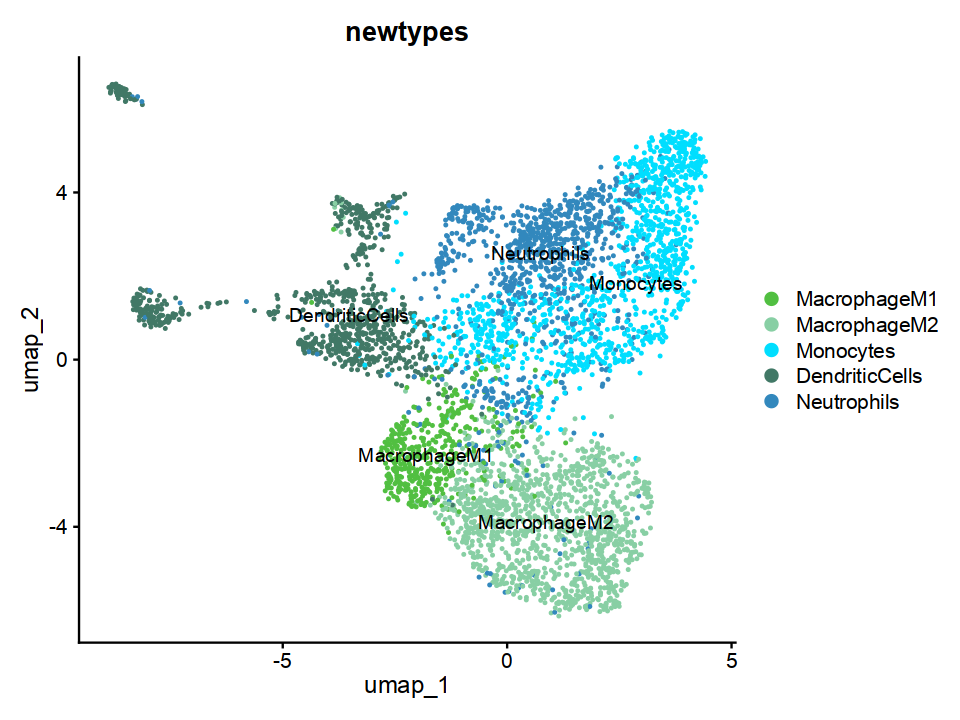

In [85]:
p_umap_myeloid

In [43]:
dot_data <- p_myloied_markergenes$data
head(dot_data)

,avg.exp,pct.exp,features.plot,id,avg.exp.scaled
,<dbl>,<dbl>,<fct>,<fct>,<dbl>
GPNMB,1.205813,10.11352,GPNMB,Neutrophils,-0.5277472
APOC1,4.668170,14.65428,APOC1,Neutrophils,-0.4372039
CD9,1.892012,18.47265,CD9,Neutrophils,-0.7196597
C1QB,2.017172,11.66151,C1QB,Neutrophils,-0.8253028
C1QC,1.796767,10.73271,C1QC,Neutrophils,-0.9560135
C1QA,1.671884,10.42312,C1QA,Neutrophils,-0.9215974


In [44]:
saveRDS(p_myloied_markergenes$data,
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig22e.Rds")

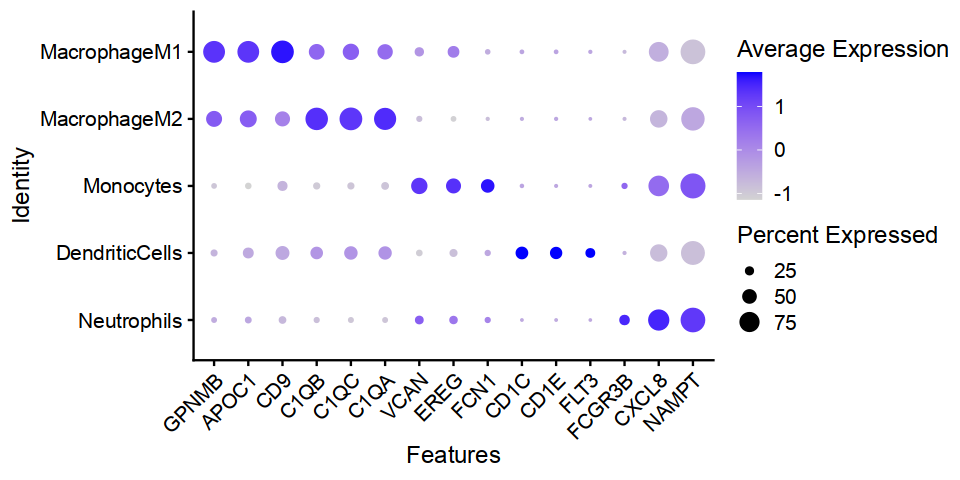

In [53]:
p_myloied_markergenes

In [81]:
ggsave(filename = "Myeloid_markergenes.bubble.pdf",plot =p_myloied_markergenes ,width = 8,height = 4)

In [87]:
ggsave(filename = "Myeloid_UMAP.pdf",plot =p_umap_myeloid ,width = 8,height = 6)

In [ ]:
Idents(GCA_obj_Myloied) <- GCA_obj_Myloied$newtypes

# find markers for every cluster compared to all remaining cells, report only the positive
GCA_obj_Myloied.markers <- FindAllMarkers(GCA_obj_Myloied, only.pos = TRUE)

GCA_obj_Myloied.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 10) %>%
    ungroup() -> top10

In [387]:
Idents(GCA_obj_Myloied)  %>% unique()

[1] Neutrophils    MacrophageM2   Monocytes      MacrophageM1   DendriticCells
Levels: Neutrophils DendriticCells Monocytes MacrophageM2 MacrophageM1

In [389]:
GCA_obj_Myloied$newtypes <- factor(GCA_obj_Myloied$newtypes,levels = c(
                'MacrophageM1','MacrophageM2','Monocytes','DendriticCells','Neutrophils'))

In [404]:
pdf(file = "Heatmap_Top10_Myeloid_differential.pdf",height = 8,width = 20)
options(repr.plot.height=6,repr.plot.width=8)
DoHeatmap(subset(GCA_obj_Myloied), features = top10$gene) + NoLegend()+
    scale_fill_gradientn(colors = c( 'lightblue',"white", "red"))
dev.off()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


png 
  2

### Tcell

In [108]:
Tcellgenes <- c( 'CD8A', 'CD8B', 'GZMK',  ## CD8
            'IL7R', 'CD40LG','CD4', ##CD4 M2
            'IKZF2', 'TNFRSF4', 'IL2RA','FOXP3', ### Tregs
            'GNLY',  'TYROBP', 'FCER1G'  ## NK
          )

In [109]:
Idents(GCA_obj_Tcell) <- 'newtypes2'

In [110]:
options(repr.plot.height=4,repr.plot.width=8)
p_Tcell_markergenes <- DotPlot(GCA_obj_Tcell, features = Tcellgenes) + RotatedAxis()

In [45]:
saveRDS(p_Tcell_markergenes$data,
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig22f.Rds")

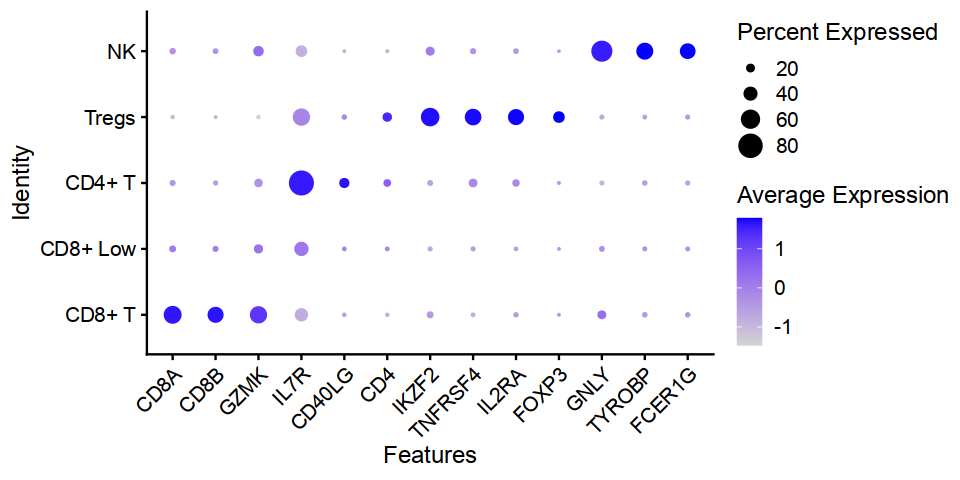

In [112]:
p_Tcell_markergenes

In [113]:
ggsave(filename = "Tcell_markergenes.bubble.pdf",plot =p_Tcell_markergenes ,width = 8,height = 4)

In [4]:
library( RColorBrewer)

In [18]:
celltyenames<- c('Epi_tumor','Epi_normal','Bcell','CD4+ T','Tregs','CD8+ T','CD8+ Low','NK','Endothelial',
    'Fibroblasts', 'Mastcell','Musclecell','MacrophageM1','MacrophageM2','DendriticCells','Monocytes',
    'Neutrophils','Pericyte','Plasma')

In [19]:
allcolors <- colorRampPalette(brewer.pal(10, "Spectral"))(19)

In [20]:
names(allcolors) <- celltyenames

In [31]:
allcolors

Epi_tumor     Epi_normal          Bcell         CD4+ T          Tregs 
     "#9E0142"      "#B91F48"      "#D53E4F"      "#E45549"      "#F46D43" 
        CD8+ T       CD8+ Low             NK    Endothelial    Fibroblasts 
     "#F88D52"      "#FDAE61"      "#d19030"      "#FEE08B"      "#F2EA91" 
      Mastcell     Musclecell   MacrophageM1   MacrophageM2 DendriticCells 
     "#E6F598"      "#C8E99E"      "#ABDDA4"      "#88CFA4"      "#66C2A5" 
     Monocytes    Neutrophils       Pericyte         Plasma 
     "#4CA4B1"      "#3288BD"      "#486BAF"      "#5E4FA2"

In [28]:
allcolors['NK'] = '#d19030'

In [32]:
allcolors['CD8+ Low'] = '#fcc38b'

In [89]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters
options(repr.plot.height=6,repr.plot.width=8)
p_tcells <- DimPlot(GCA_obj_Tcell, reduction = "umap",label = TRUE,group.by ="newtypes2",
                #    raster = TRUE,raster.dpi = c(200, 200),
                    cols = allcolors)
             #      cols = colorRampPalette(brewer.pal(10, "Spectral"))(6))

In [88]:
GCA_obj_Tcell

An object of class Seurat 
36601 features across 11825 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.cca, umap

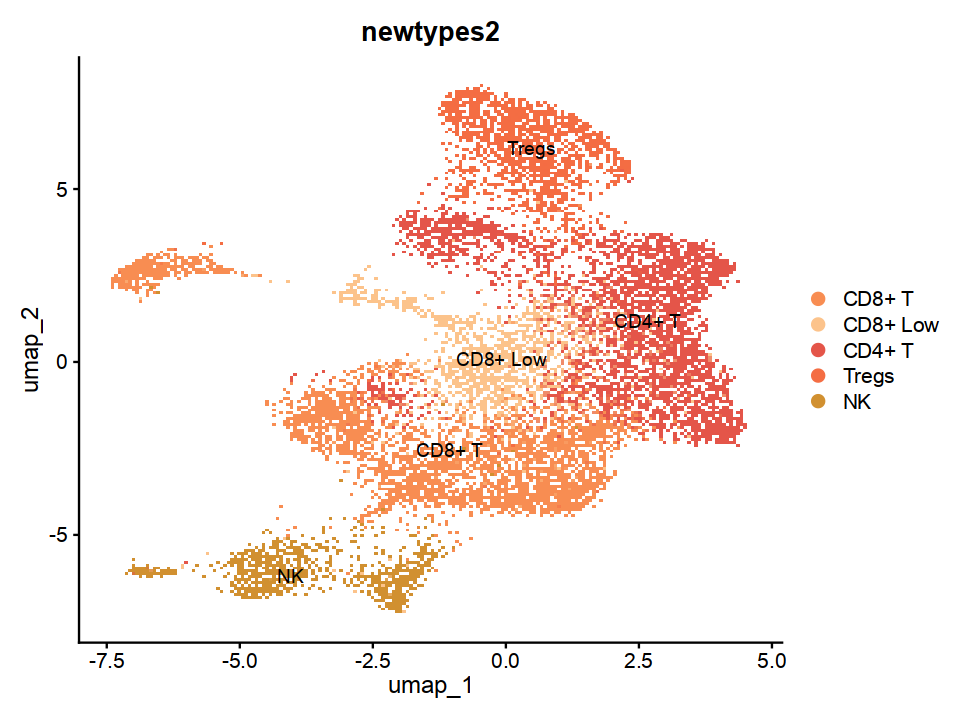

In [34]:
p_tcells

In [34]:
umap_df_T <- Embeddings(GCA_obj_Tcell, reduction = "umap")
head(umap_df_T)

,umap_1,umap_2
AAACCCAAGACTCTTG-1-SC005,-2.0742121,3.0784628
AAACCCAAGCGTTGTT-1-SC005,2.1236970,6.1317920
AAACCCAAGTACTGGG-1-SC005,-4.6762669,-5.9360147
AAACCCACAAGCTGCC-1-SC005,-1.0468897,6.2814512
AAACCCAGTCGATTTG-1-SC005,-4.2178469,-5.6979089
AAACGAAAGCCATATC-1-SC005,0.5026661,0.3097814


In [37]:
saveRDS(list(Main = cbind(GCA_obj@meta.data  %>% select(subcelltype),umap_df),
            Myeloid = cbind(GCA_obj_Myloied@meta.data  %>% select(subcelltype),umap_df_myeloid),
            Tcell = cbind(GCA_obj_Tcell@meta.data  %>% select(newtypes2),umap_df_T)),
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Figure5g.Rds")

In [90]:
ggsave(filename = "UMAP_Tcells.anno2.pdf",plot =p_tcells ,width = 8,height = 6)

In [28]:
save.image('generatefigure.Rds')

In [5]:
load('generatefigure.Rds')